In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,silhouette_score,calinski_harabasz_score

In [2]:
#2. Data collection
college_dataset = pd.read_csv('college_list.csv')
college_dataset

,College_Name,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
0,Indian Institute of Technology Madras - Campus 1,14,113042,59,9.20,8
1,National Institute of Technology Trichy - Camp...,27,115999,67,3.07,7
2,Anna University Chennai - Campus 1,22,47955,50,3.40,9
3,PSG College of Technology - Campus 1,18,67841,43,4.64,8
4,Coimbatore Institute of Technology - Campus 1,15,100640,54,4.66,9
...,...,...,...,...,...,...
495,Thiagarajar College of Engineering - Campus 17,17,106323,56,9.33,5
496,Bannari Amman Institute of Technology - Campus 17,12,39111,76,3.62,7
497,Sri Krishna College of Engineering and Technol...,16,199182,64,3.88,3
498,Sona College of Technology - Campus 17,10,46389,77,9.31,6


In [3]:
#3. Data understanding
print(college_dataset.shape)
print("======================================")
print(college_dataset.dtypes)
print("======================================")
print(college_dataset.isna().sum())
print("======================================")
college_dataset.describe()
#print("======================================")




(500, 6)
College_Name              object
Student_Faculty_Ratio      int64
Annual_Fees_INR            int64
Placement_Percentage       int64
Average_Package_LPA      float64
Infrastructure_Score       int64
dtype: object
College_Name             0
Student_Faculty_Ratio    0
Annual_Fees_INR          0
Placement_Percentage     0
Average_Package_LPA      0
Infrastructure_Score     0
dtype: int64


,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
count,500.000000,500.000000,500.000000,500.000000,500.00000
mean,18.084000,138763.710000,69.000000,6.991720,5.97600
std,6.683283,63928.678815,17.193465,2.917991,2.00486
min,8.000000,30404.000000,40.000000,2.000000,3.00000
25%,12.000000,82610.500000,53.750000,4.472500,4.00000
50%,18.000000,140290.500000,69.000000,7.155000,6.00000
75%,24.000000,193422.000000,84.000000,9.432500,8.00000
max,29.000000,249930.000000,99.000000,11.990000,9.00000


In [4]:
#clustering
X = college_dataset.drop("College_Name",axis = 1)
X

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
0,14,113042,59,9.20,8
1,27,115999,67,3.07,7
2,22,47955,50,3.40,9
3,18,67841,43,4.64,8
4,15,100640,54,4.66,9
...,...,...,...,...,...
495,17,106323,56,9.33,5
496,12,39111,76,3.62,7
497,16,199182,64,3.88,3
498,10,46389,77,9.31,6


In [5]:
#3. Data Preprocessing
standard_scalar = StandardScaler()
X_scaled = pd.DataFrame(standard_scalar.fit_transform(X))
X_scaled


,0,1,2,3,4
0,-0.611689,-0.402753,-0.582199,0.757539,1.010558
1,1.335411,-0.356452,-0.116440,-1.345326,0.511270
2,0.586526,-1.421892,-1.106178,-1.232121,1.509845
3,-0.012581,-1.110515,-1.513717,-0.806745,1.010558
4,-0.461912,-0.596945,-0.873298,-0.799884,1.509845
...,...,...,...,...,...
495,-0.162358,-0.507960,-0.756858,0.802135,-0.487305
496,-0.911243,-1.560372,0.407539,-1.156651,0.511270
497,-0.312135,0.946035,-0.291099,-1.067459,-1.485880
498,-1.210797,-1.446412,0.465759,0.795274,0.011983


In [6]:
print(round(X_scaled.mean(),4))
print(round(X_scaled.std(),4))

0    0.0
1    0.0
2   -0.0
3    0.0
4   -0.0
dtype: float64
0    1.001
1    1.001
2    1.001
3    1.001
4    1.001
dtype: float64


In [8]:
#for fiding optimal number of clusters
wcss = []
sihouette_scores = []
calinski_harabasz_scores = []
for i in range(2,11):
    k_means_test = KMeans(n_clusters=i,random_state=234)
    cluster_labels = k_means_test.fit_predict(X_scaled)
    wcss.append(k_means_test.inertia_)
    sihouette_scores.append(silhouette_score(X_scaled,cluster_labels))
    calinski_harabasz_scores.append(calinski_harabasz_score(X_scaled,cluster_labels))

print(wcss.index(max(wcss)))
print(sihouette_scores.index(max(sihouette_scores)))
print(calinski_harabasz_scores.index(max(calinski_harabasz_scores)))

0
3
0


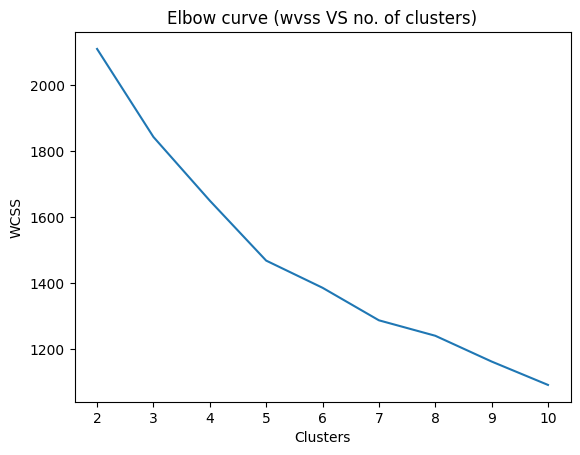

In [10]:
#Elbow curve
plt.plot(range(2,11),wcss)
plt.title(label='Elbow curve (wvss VS no. of clusters)')
plt.xlabel('Clusters')
plt.ylabel('WCSS')
plt.show()

In [11]:
k_means = KMeans(n_clusters=3,random_state=234)
k_means.fit(X_scaled)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,234
,copy_x,True
,algorithm,'lloyd'


In [12]:
k_means.labels_

array([1, 2, 2, 1, 1, 0, 2, 0, 1, 2, 0, 2, 2, 1, 0, 0, 1, 2, 0, 2, 0, 1,
       1, 0, 0, 0, 1, 0, 2, 0, 2, 0, 2, 1, 1, 0, 2, 0, 1, 2, 0, 1, 0, 0,
       1, 2, 2, 2, 0, 2, 2, 2, 0, 1, 0, 0, 1, 2, 1, 1, 1, 1, 0, 1, 1, 0,
       0, 0, 1, 1, 2, 0, 0, 2, 2, 1, 2, 0, 1, 1, 0, 0, 0, 2, 1, 0, 0, 1,
       1, 1, 1, 0, 2, 1, 2, 0, 0, 1, 1, 1, 1, 2, 1, 1, 1, 1, 2, 2, 1, 1,
       2, 2, 2, 2, 2, 0, 2, 1, 1, 2, 1, 0, 1, 1, 1, 2, 1, 1, 0, 2, 1, 2,
       2, 2, 2, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 2, 0, 1, 1, 0, 2, 2, 2, 2,
       0, 0, 0, 1, 2, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 2, 0, 0, 0, 2, 2,
       2, 2, 0, 2, 1, 1, 1, 2, 1, 2, 0, 2, 1, 1, 2, 1, 1, 2, 0, 1, 0, 1,
       1, 1, 0, 0, 2, 1, 0, 2, 2, 0, 2, 0, 2, 1, 1, 1, 0, 1, 0, 2, 0, 2,
       0, 2, 2, 0, 2, 1, 1, 2, 0, 2, 2, 2, 0, 2, 2, 1, 2, 0, 0, 2, 1, 1,
       2, 1, 1, 1, 0, 1, 1, 2, 2, 0, 1, 0, 2, 1, 0, 2, 2, 0, 1, 1, 2, 2,
       2, 0, 1, 2, 0, 0, 1, 2, 1, 0, 1, 2, 1, 1, 1, 0, 0, 0, 0, 0, 1, 2,
       2, 1, 0, 2, 0, 0, 0, 0, 1, 2, 2, 2, 2, 2, 1,

In [13]:
X["college level"] = k_means.labels_
X

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score,college level
0,14,113042,59,9.20,8,1
1,27,115999,67,3.07,7,2
2,22,47955,50,3.40,9,2
3,18,67841,43,4.64,8,1
4,15,100640,54,4.66,9,1
...,...,...,...,...,...,...
495,17,106323,56,9.33,5,0
496,12,39111,76,3.62,7,2
497,16,199182,64,3.88,3,2
498,10,46389,77,9.31,6,1


In [14]:
X.groupby("college level").agg(['mean','min','max'])

Student_Faculty_Ratio         Annual_Fees_INR         ... Average_Package_LPA        Infrastructure_Score        
                               mean min max            mean    min  ...                 min    max                 mean min max
college level                                                       ...                                                        
0                         23.901961  11  29   138902.843137  31062  ...                4.45  11.99             5.287582   3   9
1                         12.488764   8  25   158312.404494  31062  ...                2.01  11.91             6.662921   3   9
2                         18.710059   8  29   118048.000000  30404  ...                2.00   9.71             5.875740   3   9

[3 rows x 15 columns]

In [15]:
#randing based on placement and fees
college_rank = {2:"Best",0:"Mid-level",1:"Emerging"}
X["Category"] = X["college level"].map(college_rank)
X

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score,college level,Category
0,14,113042,59,9.20,8,1,Emerging
1,27,115999,67,3.07,7,2,Best
2,22,47955,50,3.40,9,2,Best
3,18,67841,43,4.64,8,1,Emerging
4,15,100640,54,4.66,9,1,Emerging
...,...,...,...,...,...,...,...
495,17,106323,56,9.33,5,0,Mid-level
496,12,39111,76,3.62,7,2,Best
497,16,199182,64,3.88,3,2,Best
498,10,46389,77,9.31,6,1,Emerging


In [16]:
#4. Model selection
input_dataset = X.drop(["college level","Category"],axis = 1)
output_dataset = X["college level"]
X_train,X_test,y_train,y_test = train_test_split(input_dataset,output_dataset,test_size=0.2,random_state=123,shuffle=True,stratify = output_dataset)

In [17]:
#5. Model Training
random_forest = RandomForestClassifier(random_state=12)
random_forest.fit(X_train,y_train)
y_pred = random_forest.predict(X_test)

print("Accuracy score:",accuracy_score(y_test,y_pred))

Accuracy score: 0.89
